# Fuel price distributions

Quick visualization of the triangular gas and coal price distributions with a sample size of 100.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from distributions import sample_triangular
from general_parameters import COAL_PRICE_DISTRIBUTION, GAS_PRICE_DISTRIBUTION

In [2]:
SAMPLE_SIZE = 10000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

gas_samples = sample_triangular(GAS_PRICE_DISTRIBUTION, size=SAMPLE_SIZE, rng=rng)
coal_samples = sample_triangular(COAL_PRICE_DISTRIBUTION, size=SAMPLE_SIZE, rng=rng)

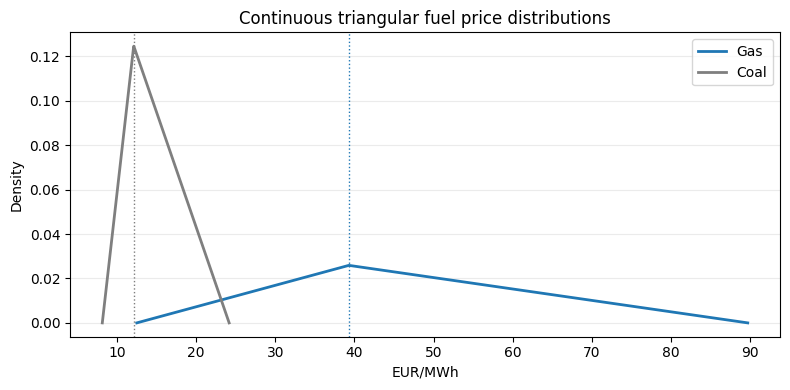

In [3]:
def triangular_pdf(x, distribution):
    minimum = distribution.minimum
    mode = distribution.mode
    maximum = distribution.maximum

    pdf = np.zeros_like(x, dtype=float)
    rising = (minimum <= x) & (x <= mode)
    falling = (mode < x) & (x <= maximum)

    pdf[rising] = 2 * (x[rising] - minimum) / ((maximum - minimum) * (mode - minimum))
    pdf[falling] = 2 * (maximum - x[falling]) / ((maximum - minimum) * (maximum - mode))
    return pdf


fig, ax = plt.subplots(figsize=(8, 4))

for label, distribution, color in [
    ("Gas", GAS_PRICE_DISTRIBUTION, "tab:blue"),
    ("Coal", COAL_PRICE_DISTRIBUTION, "tab:gray"),
]:
    x = np.linspace(distribution.minimum, distribution.maximum, 500)
    ax.plot(x, triangular_pdf(x, distribution), label=label, color=color, linewidth=2)
    ax.axvline(distribution.mode, color=color, linestyle=":", linewidth=1)

ax.set_title("Continuous triangular fuel price distributions")
ax.set_xlabel("EUR/MWh")
ax.set_ylabel("Density")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

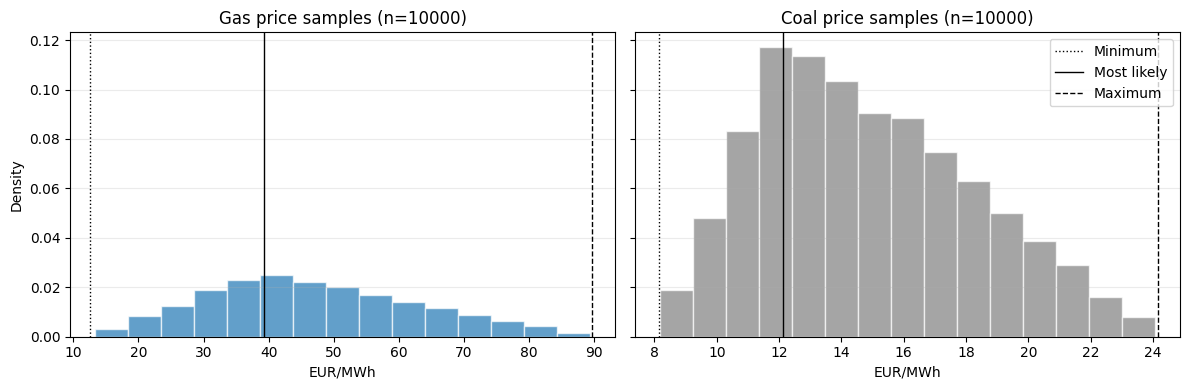

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plots = [
    ("Gas", gas_samples, GAS_PRICE_DISTRIBUTION, "tab:blue"),
    ("Coal", coal_samples, COAL_PRICE_DISTRIBUTION, "tab:gray"),
]

for ax, (label, samples, distribution, color) in zip(axes, plots):
    ax.hist(samples, bins=15, density=True, alpha=0.7, color=color, edgecolor="white")
    ax.axvline(distribution.minimum, color="black", linestyle=":", linewidth=1, label="Minimum")
    ax.axvline(distribution.mode, color="black", linestyle="-", linewidth=1, label="Most likely")
    ax.axvline(distribution.maximum, color="black", linestyle="--", linewidth=1, label="Maximum")
    ax.set_title(f"{label} price samples (n={SAMPLE_SIZE})")
    ax.set_xlabel(distribution.unit)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Density")
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

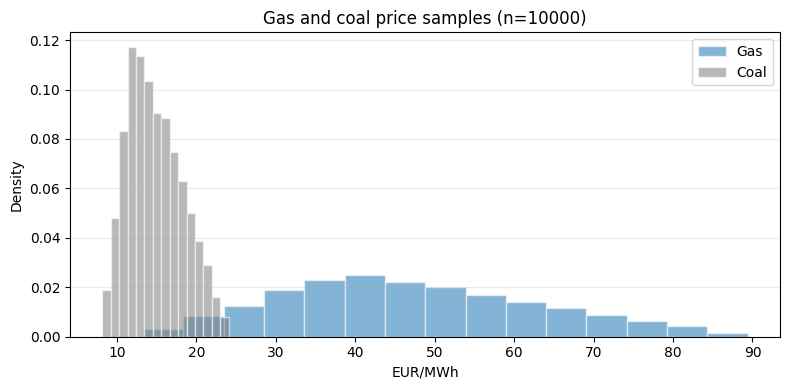

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(gas_samples, bins=15, density=True, alpha=0.55, label="Gas", color="tab:blue", edgecolor="white")
ax.hist(coal_samples, bins=15, density=True, alpha=0.55, label="Coal", color="tab:gray", edgecolor="white")
ax.set_title(f"Gas and coal price samples (n={SAMPLE_SIZE})")
ax.set_xlabel("EUR/MWh")
ax.set_ylabel("Density")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()